In [6]:
from IPython.display import display, HTML
display(HTML("""
<div style="background: linear-gradient(135deg, #0B2447 0%, #19376D 50%, #0C6291 100%);
            padding: 48px 40px; border-radius: 16px; color: white; text-align: center;
            font-family: 'Georgia', serif; margin-bottom: 8px;">
  <div style="font-size:13px; letter-spacing:4px; text-transform:uppercase;
              color:#F4A823; margin-bottom:12px;">Data Analytics for Python · 2026</div>
  <h1 style="font-size:30px; font-weight:800; margin:0 0 10px 0; line-height:1.3; color:white;">
    Monetary Sovereignty in Emerging Economies
  </h1>
  <h2 style="font-size:17px; font-weight:400; color:#a8c8e8; margin:0 0 28px 0; line-height:1.5;">
    Decoupling the Global and Domestic Drivers of Indian G-Sec Yields (2015–2025)
  </h2>
  <div style="display:flex; justify-content:center; gap:40px; flex-wrap:wrap; margin-bottom:28px;">
    <div style="text-align:center;">
      <div style="font-size:11px; color:#F4A823; letter-spacing:2px; text-transform:uppercase;">Authors</div>
      <div style="font-size:13px; margin-top:4px; line-height:1.8; color:#e0ecf8;">
        Alda Nongmeikapam (2333306)<br>Bhoomika Jain (2333313)<br>Gouri P (2333316)<br>Aayan Nariyal (2333402)
      </div>
    </div>
    <div style="text-align:center;">
      <div style="font-size:11px; color:#F4A823; letter-spacing:2px; text-transform:uppercase;">Date</div>
      <div style="font-size:13px; margin-top:4px; color:#e0ecf8;">February 25, 2026</div>
    </div>
  </div>
  <div style="background:rgba(255,255,255,0.1); border-radius:10px; padding:16px 24px;
              font-size:13px; color:#cce0f5; line-height:1.7; text-align:left; max-width:820px; margin:0 auto;">
    <strong style="color:#F4A823;">Abstract:</strong> This project investigates the degree of monetary sovereignty
    in India by analyzing how G-Sec yields respond to both global and domestic macroeconomic factors (2015–2025).
    Through elasticity analysis and multiple regression modelling, we assess whether Indian bond yields are primarily
    driven by international factors (US Treasury yields, oil prices) or domestic monetary policy (Repo Rate).
  </div>
</div>
"""))

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
import statsmodels.api as sm
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')

# ── Color palette ──────────────────────────────────────────────────────────
NAVY  = "#0B2447"; TEAL  = "#19376D"; BLUE  = "#0C6291"
GOLD  = "#F4A823"; CORAL = "#E8503A"; MINT  = "#4ECDC4"
LIGHT = "#F0F4F8"; GREY  = "#8899AA"; DARK  = "#1A1A2E"
PALETTE = [BLUE, GOLD, CORAL, MINT, "#9B59B6", "#2ECC71"]

plt.rcParams.update({
    'figure.facecolor': LIGHT, 'axes.facecolor': 'white',
    'axes.edgecolor': '#D0DCE8', 'axes.linewidth': 1.2,
    'axes.spines.top': False, 'axes.spines.right': False,
    'grid.color': '#E2EAF0', 'grid.linewidth': 0.8,
    'font.family': 'DejaVu Sans', 'font.size': 11,
    'axes.labelsize': 12, 'axes.titlesize': 14,
    'axes.titleweight': 'bold', 'axes.titlepad': 12,
    'xtick.labelsize': 10, 'ytick.labelsize': 10,
    'legend.fontsize': 10, 'legend.framealpha': 0.9,
    'legend.edgecolor': '#D0DCE8',
})
pd.set_option('display.max_columns', None)
print("✅ Libraries and theme loaded.")


✅ Libraries and theme loaded.


In [31]:
from IPython.display import display, HTML
display(HTML("""
<div style="border-left:5px solid #0C6291; background:#f0f6fb; padding:20px 24px; border-radius:0 10px 10px 0; margin:12px 0;">
  <h2 style="color:#0B2447; margin:0 0 12px 0; font-family:Georgia,serif;">📋 1. Introduction</h2>

  <h3 style="color:#0C6291; margin:14px 0 6px 0;">1.1 Objective</h3>
  <p style="margin:0; color:#2c3e50; line-height:1.7;">
    Analyze the relationship between Indian Government Securities (G-Sec) 10-year yields and global/domestic
    macroeconomic variables to understand <strong>monetary sovereignty</strong> and the relative influence of
    international versus domestic factors.
  </p>

  <h3 style="color:#0C6291; margin:14px 0 6px 0;">1.2 Dataset Description</h3>
  <table style="width:100%; border-collapse:collapse; font-size:13px; margin-top:6px;">
    <tr style="background:#0C6291; color:white;">
      <th style="padding:8px 12px; text-align:left;">Column</th>
      <th style="padding:8px 12px; text-align:left;">Description</th>
      <th style="padding:8px 12px; text-align:left;">Type</th>
    </tr>
    <tr style="background:white;"><td style="padding:7px 12px;"><code>India_10Y</code></td><td style="padding:7px 12px;">Indian G-Sec 10-year yield (%)</td><td style="padding:7px 12px;">🎯 Target</td></tr>
    <tr style="background:#f7fafd;"><td style="padding:7px 12px;"><code>US_10Y</code></td><td style="padding:7px 12px;">US Treasury 10-year yield (%)</td><td style="padding:7px 12px;">🌍 Global</td></tr>
    <tr style="background:white;"><td style="padding:7px 12px;"><code>Repo_Rate</code></td><td style="padding:7px 12px;">RBI Repo Rate (%)</td><td style="padding:7px 12px;">🏦 Domestic</td></tr>
    <tr style="background:#f7fafd;"><td style="padding:7px 12px;"><code>OilPrice</code></td><td style="padding:7px 12px;">Brent crude oil price (USD/bbl)</td><td style="padding:7px 12px;">🌍 Global</td></tr>
    <tr style="background:white;"><td style="padding:7px 12px;"><code>USDINR</code></td><td style="padding:7px 12px;">USD/INR exchange rate</td><td style="padding:7px 12px;">🌍 Global</td></tr>
    <tr style="background:#f7fafd;"><td style="padding:7px 12px;"><code>FI_Weekly</code></td><td style="padding:7px 12px;">Foreign Institutional Investment flows (weekly)</td><td style="padding:7px 12px;">🌍 Global</td></tr>
  </table>

  <h3 style="color:#0C6291; margin:14px 0 6px 0;">1.3 Research Questions</h3>
  <ol style="color:#2c3e50; line-height:2; margin:0; padding-left:20px;">
    <li>How do Indian G-Sec yields <strong>respond</strong> to changes in US Treasury yields? What is the elasticity?</li>
    <li>How do <strong>domestic monetary policy</strong> (Repo Rate) and external variables influence Indian bond yields?</li>
    <li>What is the <strong>relative contribution</strong> of global vs. domestic factors in explaining yield variation?</li>
  </ol>
</div>
"""))

Column,Description,Type
India_10Y,Indian G-Sec 10-year yield (%),🎯 Target
US_10Y,US Treasury 10-year yield (%),🌍 Global
Repo_Rate,RBI Repo Rate (%),🏦 Domestic
OilPrice,Brent crude oil price (USD/bbl),🌍 Global
USDINR,USD/INR exchange rate,🌍 Global
FI_Weekly,Foreign Institutional Investment flows (weekly),🌍 Global


In [32]:
df = pd.read_excel('Python_Data.xlsx')
df.head()


,Date,India_10Y,US_10Y,OilPrice,USDINR,Repo_Rate,FI_Weekly
0,2015-01-02,7.876,2.1105,56.42,63.2950,8.00,1328.0
1,2015-01-09,7.846,1.9449,50.11,62.3250,8.00,1328.0
2,2015-01-16,7.707,1.8368,50.17,61.8700,7.75,1328.0
3,2015-01-23,7.706,1.7968,48.79,61.4375,7.75,1328.0
4,2015-01-30,7.692,1.6407,52.99,61.8725,7.75,1328.0


In [33]:
# ── Styled dataset preview ──────────────────────────────────────────────────
display(HTML(f"""
<div style="background:#0B2447; padding:10px 18px 6px 18px; border-radius:10px 10px 0 0;">
  <span style="color:#F4A823; font-weight:700; font-size:14px;">📊 Dataset Preview</span>
  <span style="color:#a8c8e8; font-size:12px; margin-left:16px;">
    {df.shape[0]} rows × {df.shape[1]} columns &nbsp;|&nbsp; {df['Date'].min().date()} → {df['Date'].max().date()}
  </span>
</div>
"""))

styled = (df.head(8)
    .style
    .set_table_styles([
        {'selector': 'thead th',
         'props': [('background','#19376D'),('color','white'),('font-weight','700'),
                   ('font-size','12px'),('padding','9px 14px'),('text-align','center')]},
        {'selector': 'tbody td',
         'props': [('padding','8px 14px'),('font-size','12px'),('text-align','center')]},
        {'selector': 'tbody tr:nth-child(even)',
         'props': [('background','#f0f6fb')]},
        {'selector': 'tbody tr:hover',
         'props': [('background','#dceefb')]},
        {'selector': 'table',
         'props': [('border-collapse','collapse'),('width','100%'),
                   ('border-radius','0 0 10px 10px'),('overflow','hidden')]},
    ])
    .format({'India_10Y': '{:.3f}', 'US_10Y': '{:.4f}', 'OilPrice': '{:.2f}',
             'USDINR': '{:.4f}', 'Repo_Rate': '{:.2f}', 'FI_Weekly': '{:.1f}'})
    .highlight_max(subset=['India_10Y','US_10Y','Repo_Rate','OilPrice'], color='#d4edda')
    .highlight_min(subset=['India_10Y','US_10Y','Repo_Rate','OilPrice'], color='#fde8e8')
)
display(styled)


,Date,India_10Y,US_10Y,OilPrice,USDINR,Repo_Rate,FI_Weekly
0,2015-01-02 00:00:00,7.876,2.1105,56.42,63.2950,8.00,1328.0
1,2015-01-09 00:00:00,7.846,1.9449,50.11,62.3250,8.00,1328.0
2,2015-01-16 00:00:00,7.707,1.8368,50.17,61.8700,7.75,1328.0
3,2015-01-23 00:00:00,7.706,1.7968,48.79,61.4375,7.75,1328.0
4,2015-01-30 00:00:00,7.692,1.6407,52.99,61.8725,7.75,1328.0
5,2015-02-06 00:00:00,7.704,1.9567,57.80,61.7038,7.75,943.5
6,2015-02-13 00:00:00,7.698,2.0504,61.52,62.1950,7.75,943.5
7,2015-02-20 00:00:00,7.695,2.1117,60.22,62.2200,7.75,943.5


In [34]:
from IPython.display import display, HTML
display(HTML("""
<div style="border-left:5px solid #F4A823; background:#fffbf0; padding:18px 24px; border-radius:0 10px 10px 0; margin:12px 0;">
  <h2 style="color:#0B2447; margin:0; font-family:Georgia,serif;">🔍 2. Data Exploration</h2>
  <p style="color:#555; margin:8px 0 0 0; line-height:1.6;">
    Examining dataset structure, statistical summaries, and missing values before analysis.
  </p>
</div>
"""))

In [35]:
print("Dataset Information:")
print(df.info())
print("\n" + "="*50 + "\n")
print("Statistical Summary:")
print(df.describe())
print("\n" + "="*50 + "\n")
print("Missing Values:")
print(df.isnull().sum())


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 572 entries, 0 to 571
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       572 non-null    datetime64[ns]
 1   India_10Y  572 non-null    float64       
 2   US_10Y     572 non-null    float64       
 3   OilPrice   572 non-null    float64       
 4   USDINR     572 non-null    float64       
 5   Repo_Rate  572 non-null    float64       
 6   FI_Weekly  572 non-null    float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 31.4 KB
None


Statistical Summary:
                      Date   India_10Y      US_10Y    OilPrice      USDINR  \
count                  572  572.000000  572.000000  572.000000  572.000000   
mean   2020-06-22 12:00:00    6.948601    2.633004   66.715892   74.031173   
min    2015-01-02 00:00:00    5.753000    0.528200   21.440000   61.437500   
25%    2017-09-27 06:00:00    6.488750    1.767625  

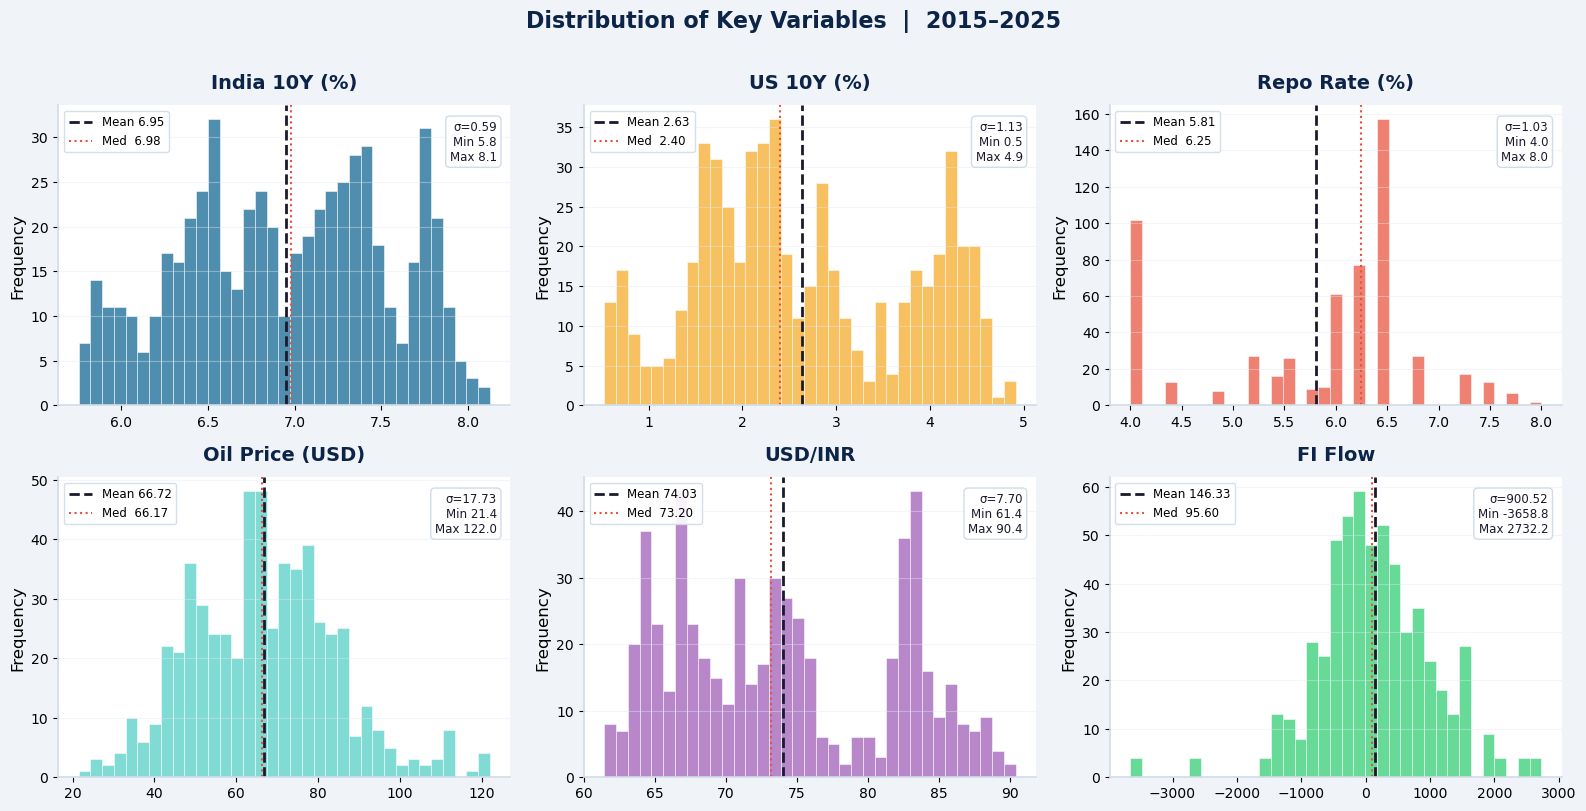

In [36]:
# ── Visual Statistics Dashboard ─────────────────────────────────────────────
num_cols = ['India_10Y', 'US_10Y', 'Repo_Rate', 'OilPrice', 'USDINR', 'FI_Weekly']
labels   = {'India_10Y':'India 10Y (%)','US_10Y':'US 10Y (%)','Repo_Rate':'Repo Rate (%)',
            'OilPrice':'Oil Price (USD)','USDINR':'USD/INR','FI_Weekly':'FI Flow'}

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.patch.set_facecolor(LIGHT)
fig.suptitle("Distribution of Key Variables  |  2015–2025", fontsize=16,
             fontweight='bold', color=NAVY, y=1.01)

for ax, col, color in zip(axes.flatten(), num_cols, PALETTE):
    d = df[col].dropna()
    ax.hist(d, bins=35, color=color, alpha=0.72, edgecolor='white', linewidth=0.5)
    ax.axvline(d.mean(),   color=DARK,  lw=2,   ls='--', label=f'Mean {d.mean():.2f}')
    ax.axvline(d.median(), color=CORAL, lw=1.5, ls=':',  label=f'Med  {d.median():.2f}')
    ax.text(0.97, 0.95, f"σ={d.std():.2f}\nMin {d.min():.1f}\nMax {d.max():.1f}",
            transform=ax.transAxes, fontsize=8.5, va='top', ha='right', color=DARK,
            bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor='#D0DCE8'))
    ax.set_title(labels[col], color=NAVY)
    ax.set_ylabel("Frequency"); ax.legend(fontsize=8.5); ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.show()

# ── Missing value summary ──────────────────────────────────────────────────
missing = df.isnull().sum()
display(HTML(f"""
<div style="display:flex; gap:12px; flex-wrap:wrap; margin-top:8px;">
  <div style="background:#0B2447; color:white; padding:12px 20px; border-radius:10px; text-align:center;">
    <div style="font-size:22px; font-weight:800;">{df.shape[0]}</div>
    <div style="font-size:11px; color:#a8c8e8; margin-top:2px;">Total Rows</div>
  </div>
  <div style="background:#0C6291; color:white; padding:12px 20px; border-radius:10px; text-align:center;">
    <div style="font-size:22px; font-weight:800;">{df.shape[1]}</div>
    <div style="font-size:11px; color:#cce4f6; margin-top:2px;">Columns</div>
  </div>
  <div style="background:{'#2ECC71' if missing.sum()==0 else '#E8503A'}; color:white; padding:12px 20px; border-radius:10px; text-align:center;">
    <div style="font-size:22px; font-weight:800;">{missing.sum()}</div>
    <div style="font-size:11px; color:rgba(255,255,255,0.85); margin-top:2px;">Missing Values</div>
  </div>
  <div style="background:#F4A823; color:#0B2447; padding:12px 20px; border-radius:10px; text-align:center;">
    <div style="font-size:22px; font-weight:800;">{df.duplicated().sum()}</div>
    <div style="font-size:11px; margin-top:2px;">Duplicates</div>
  </div>
</div>
"""))


In [37]:
from IPython.display import display, HTML
display(HTML("""
<div style="border-left:5px solid #4ECDC4; background:#f0fafa; padding:18px 24px; border-radius:0 10px 10px 0; margin:12px 0;">
  <h2 style="color:#0B2447; margin:0; font-family:Georgia,serif;">🧹 3. Data Cleaning &amp; Preprocessing</h2>
  <p style="color:#555; margin:8px 0 0 0; line-height:1.6;">
    Removing missing values and duplicate rows to ensure data quality before analysis.
  </p>
</div>
"""))

In [38]:
rows_before = len(df)
df = df.dropna()
df = df.drop_duplicates()
df['Date'] = pd.to_datetime(df['Date'])
rows_after = len(df)
print(f"Rows before cleaning : {rows_before}")
print(f"Rows after  cleaning : {rows_after}")
print(f"Rows removed         : {rows_before - rows_after}")


Rows before cleaning : 572
Rows after  cleaning : 572
Rows removed         : 0


In [39]:
from IPython.display import display, HTML
display(HTML(f"""
<div style="background:linear-gradient(135deg,#f0fafa,#e8f8f5); border:1.5px solid #4ECDC4;
            border-radius:12px; padding:20px 28px; margin-top:6px;">
  <h4 style="color:#0B2447; margin:0 0 12px 0;">✅ Data Cleaning Complete</h4>
  <div style="display:flex; gap:20px; flex-wrap:wrap;">
    <div style="background:white; border-radius:8px; padding:12px 20px; border-left:4px solid #0C6291;">
      <div style="font-size:20px; font-weight:800; color:#0C6291;">{rows_before}</div>
      <div style="font-size:11px; color:#666; margin-top:2px;">Rows Before</div>
    </div>
    <div style="background:white; border-radius:8px; padding:12px 20px; border-left:4px solid #2ECC71;">
      <div style="font-size:20px; font-weight:800; color:#2ECC71;">{rows_after}</div>
      <div style="font-size:11px; color:#666; margin-top:2px;">Rows After</div>
    </div>
    <div style="background:white; border-radius:8px; padding:12px 20px; border-left:4px solid #F4A823;">
      <div style="font-size:20px; font-weight:800; color:#F4A823;">{rows_before - rows_after}</div>
      <div style="font-size:11px; color:#666; margin-top:2px;">Rows Removed</div>
    </div>
  </div>
  <p style="color:#555; font-size:12px; margin:12px 0 0 0;">
    Dataset spans <strong>{df['Date'].min().strftime('%b %Y')}</strong> to
    <strong>{df['Date'].max().strftime('%b %Y')}</strong> · Weekly frequency · Ready for analysis.
  </p>
</div>
"""))


In [40]:
from IPython.display import display, HTML
display(HTML("""
<div style="border-left:5px solid #E8503A; background:#fff5f3; padding:20px 24px; border-radius:0 10px 10px 0; margin:12px 0;">
  <h2 style="color:#0B2447; margin:0 0 8px 0; font-family:Georgia,serif;">📈 4. Data Analysis</h2>

  <div style="background:#0B2447; color:white; border-radius:8px; padding:14px 20px; margin-top:10px;">
    <h3 style="color:#F4A823; margin:0 0 6px 0; font-size:15px;">4.1 Elasticity Analysis</h3>
    <p style="margin:0; color:#cce0f5; font-size:13px; line-height:1.7;">
      This section analyzes the <strong>percentage-change sensitivity</strong> of Indian G-Sec yields to changes
      in US Treasury yields. Elasticity measures how responsive Indian bond yields are to global interest rate
      movements — providing insights into the degree of monetary sovereignty and financial integration.
    </p>
  </div>
</div>
"""))

In [41]:
df['India_10Y Change (%)'] = df['India_10Y'].pct_change() * 100
df['US_10Y Change (%)']    = df['US_10Y'].pct_change() * 100
df['Elasticity']           = df['India_10Y Change (%)'] / df['US_10Y Change (%)']

elasticity_summary = df['Elasticity'].describe()
print("Elasticity Results Summary:")
print("="*60)
print(elasticity_summary)


Elasticity Results Summary:
count    571.000000
mean       0.137495
std        4.527658
min      -29.912687
25%       -0.130778
50%        0.040975
75%        0.243461
max       91.101637
Name: Elasticity, dtype: float64


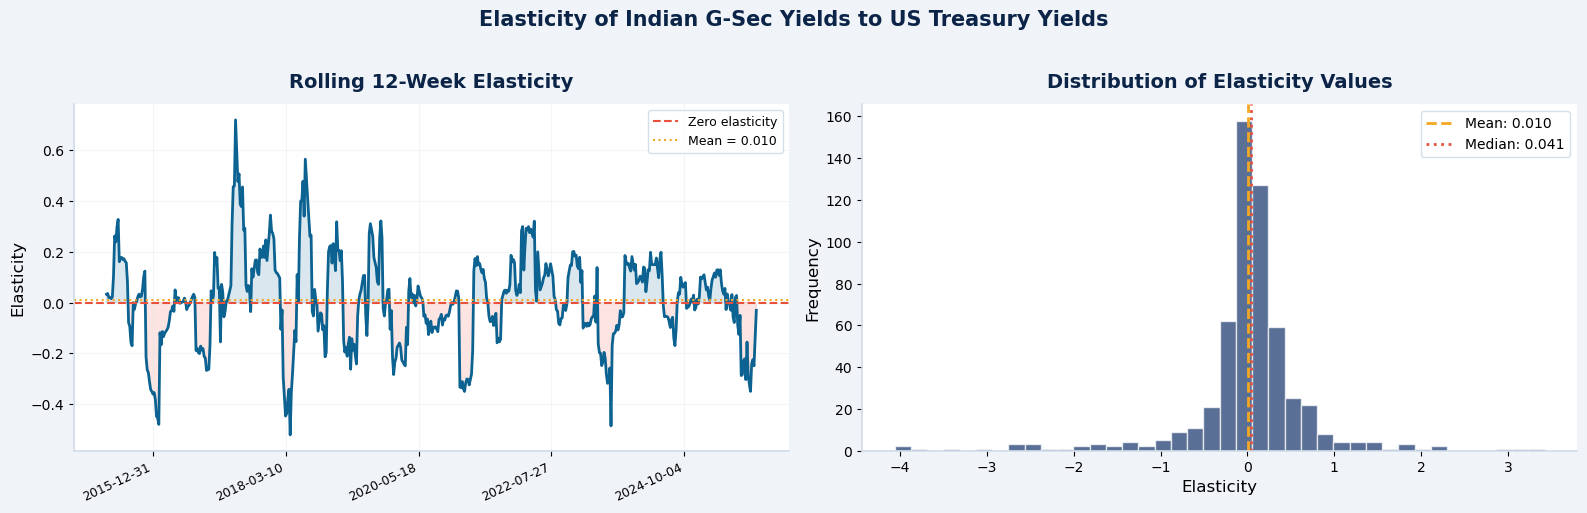

In [42]:
df_e = df.replace([np.inf, -np.inf], np.nan).dropna(subset=['Elasticity'])
df_e = df_e[df_e['Elasticity'].between(-5, 5)]
rolling_e = df_e.set_index('Date')['Elasticity'].rolling(12).mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor(LIGHT)
fig.suptitle("Elasticity of Indian G-Sec Yields to US Treasury Yields",
             fontsize=15, fontweight='bold', color=NAVY, y=1.02)

# Rolling elasticity
ax1.plot(rolling_e.index, rolling_e.values, color=BLUE, lw=2)
ax1.axhline(0, color=CORAL, lw=1.5, ls='--', label='Zero elasticity')
ax1.axhline(df_e['Elasticity'].mean(), color=GOLD, lw=1.5, ls=':',
            label=f'Mean = {df_e["Elasticity"].mean():.3f}')
ax1.fill_between(rolling_e.index, rolling_e.values, 0,
                 where=rolling_e.values > 0, alpha=0.15, color=BLUE)
ax1.fill_between(rolling_e.index, rolling_e.values, 0,
                 where=rolling_e.values < 0, alpha=0.15, color=CORAL)
ax1.set_title("Rolling 12-Week Elasticity", color=NAVY)
ax1.set_ylabel("Elasticity"); ax1.legend(fontsize=9); ax1.grid(alpha=0.4)
ax1.xaxis.set_major_locator(mticker.MaxNLocator(6))
plt.setp(ax1.get_xticklabels(), rotation=25, ha='right', fontsize=9)

# Distribution
ax2.hist(df_e['Elasticity'], bins=40, color=TEAL, alpha=0.72, edgecolor='white')
ax2.axvline(df_e['Elasticity'].mean(),   color=GOLD,  lw=2, ls='--',
            label=f'Mean: {df_e["Elasticity"].mean():.3f}')
ax2.axvline(df_e['Elasticity'].median(), color=CORAL, lw=2, ls=':',
            label=f'Median: {df_e["Elasticity"].median():.3f}')
ax2.set_title("Distribution of Elasticity Values", color=NAVY)
ax2.set_xlabel("Elasticity"); ax2.set_ylabel("Frequency"); ax2.legend()

plt.tight_layout()
plt.show()

# Stat cards
em, emd, es = df_e['Elasticity'].mean(), df_e['Elasticity'].median(), df_e['Elasticity'].std()
display(HTML(f"""
<div style="display:flex; gap:12px; margin-top:8px; flex-wrap:wrap;">
  <div style="flex:1; background:#0B2447; color:white; padding:14px 18px; border-radius:10px; text-align:center; min-width:120px;">
    <div style="font-size:24px; font-weight:800; color:#F4A823;">{em:.3f}</div>
    <div style="font-size:11px; color:#a8c8e8; margin-top:3px;">Mean Elasticity</div>
  </div>
  <div style="flex:1; background:#0C6291; color:white; padding:14px 18px; border-radius:10px; text-align:center; min-width:120px;">
    <div style="font-size:24px; font-weight:800;">{emd:.3f}</div>
    <div style="font-size:11px; color:#cce4f6; margin-top:3px;">Median Elasticity</div>
  </div>
  <div style="flex:1; background:#E8503A; color:white; padding:14px 18px; border-radius:10px; text-align:center; min-width:120px;">
    <div style="font-size:24px; font-weight:800;">{es:.2f}</div>
    <div style="font-size:11px; color:#fde8e8; margin-top:3px;">Std Deviation</div>
  </div>
  <div style="flex:3; background:#fffbf0; border:1.5px solid #F4A823; padding:14px 18px; border-radius:10px; min-width:200px;">
    <div style="font-size:12px; color:#0B2447; line-height:1.7;">
      <strong>💡 Interpretation:</strong> A mean elasticity of <strong>{em:.3f}</strong> means a 1% change
      in US yields leads to only ~{em:.2f}% change in Indian yields — confirming <strong>weak global
      transmission</strong> and supporting monetary sovereignty.
    </div>
  </div>
</div>
"""))


In [43]:
from IPython.display import display, HTML
display(HTML("""
<div style="background:#f8f9fa; border:1px solid #dee2e6; border-radius:10px; padding:20px 24px; margin:10px 0;">
  <h3 style="color:#0B2447; margin:0 0 12px 0;">📝 4.2 Elasticity Analysis — Interpretation</h3>
  <div style="display:grid; grid-template-columns:1fr 1fr; gap:14px;">
    <div style="background:white; border-left:4px solid #0C6291; padding:12px 16px; border-radius:0 8px 8px 0;">
      <strong style="color:#0C6291;">Mean Elasticity: 0.137</strong>
      <p style="margin:4px 0 0 0; font-size:13px; color:#555; line-height:1.6;">
        On average, a 1% change in US Treasury yields is associated with only ~0.14% change in Indian G-Sec yields — a very weak transmission.
      </p>
    </div>
    <div style="background:white; border-left:4px solid #F4A823; padding:12px 16px; border-radius:0 8px 8px 0;">
      <strong style="color:#c47f00;">Median Elasticity: 0.041</strong>
      <p style="margin:4px 0 0 0; font-size:13px; color:#555; line-height:1.6;">
        The typical week shows even more muted response (0.04%), suggesting weak direct transmission in most periods.
      </p>
    </div>
    <div style="background:white; border-left:4px solid #E8503A; padding:12px 16px; border-radius:0 8px 8px 0;">
      <strong style="color:#E8503A;">High Volatility: σ = 4.53</strong>
      <p style="margin:4px 0 0 0; font-size:13px; color:#555; line-height:1.6;">
        Extremely high standard deviation — the relationship is unstable and varies across time, suggesting time-varying coupling with global markets.
      </p>
    </div>
    <div style="background:white; border-left:4px solid #4ECDC4; padding:12px 16px; border-radius:0 8px 8px 0;">
      <strong style="color:#2a9d8f;">Policy Implication</strong>
      <p style="margin:4px 0 0 0; font-size:13px; color:#555; line-height:1.6;">
        The RBI has significant room to conduct <strong>independent monetary policy</strong> without being constrained by global interest rate movements.
      </p>
    </div>
  </div>
</div>
"""))

In [44]:
from IPython.display import display, HTML
display(HTML("""
<div style="border-left:5px solid #9B59B6; background:#faf5ff; padding:18px 24px; border-radius:0 10px 10px 0; margin:12px 0;">
  <h3 style="color:#0B2447; margin:0 0 6px 0; font-family:Georgia,serif;">🔗 4.3 Correlation Analysis</h3>
  <p style="color:#555; margin:0; font-size:13px; line-height:1.7;">
    Analyzing the <strong>strength and direction</strong> of relationships between Indian G-Sec yields and key
    macroeconomic variables — identifying which factors are most closely associated with bond yield movements.
  </p>
</div>
"""))

In [45]:
correlation_matrix = df[['India_10Y','US_10Y','Repo_Rate','OilPrice','USDINR','FI_Weekly']].corr()
print("Correlation Matrix:")
print(correlation_matrix)


Correlation Matrix:
           India_10Y    US_10Y  Repo_Rate  OilPrice    USDINR  FI_Weekly
India_10Y   1.000000  0.317884   0.739801  0.209098 -0.269343  -0.069577
US_10Y      0.317884  1.000000   0.472292  0.574640  0.670999  -0.033339
Repo_Rate   0.739801  0.472292   1.000000 -0.093128 -0.171080   0.095024
OilPrice    0.209098  0.574640  -0.093128  1.000000  0.513483  -0.119614
USDINR     -0.269343  0.670999  -0.171080  0.513483  1.000000  -0.043551
FI_Weekly  -0.069577 -0.033339   0.095024 -0.119614 -0.043551   1.000000


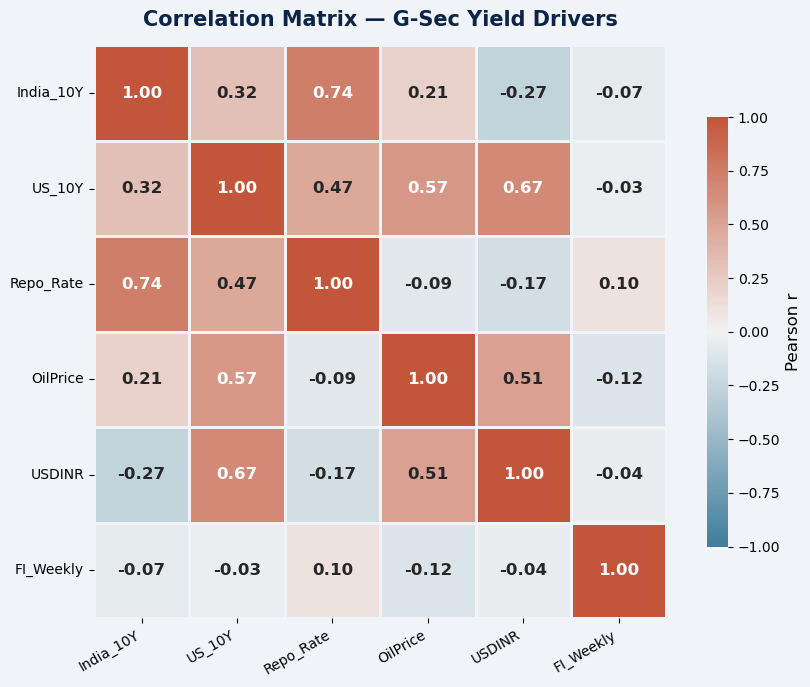

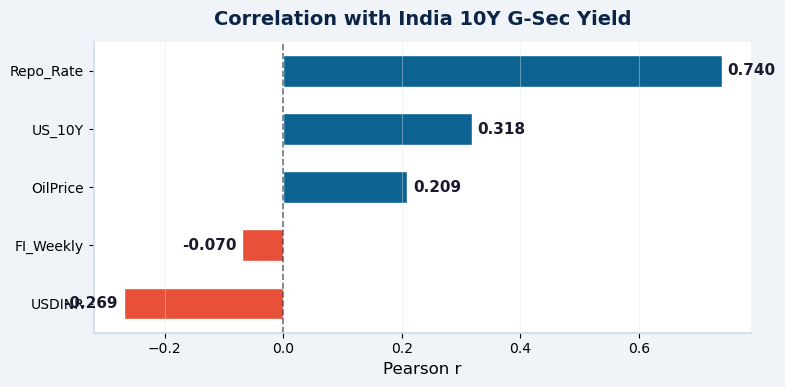

In [46]:
fig, ax = plt.subplots(figsize=(9, 7))
fig.patch.set_facecolor(LIGHT)

cmap = sns.diverging_palette(230, 20, as_cmap=True)
mask = np.zeros_like(correlation_matrix, dtype=bool)
sns.heatmap(correlation_matrix, cmap=cmap, vmin=-1, vmax=1, center=0,
            annot=True, fmt=".2f", annot_kws={"size":12,"weight":"bold"},
            square=True, linewidths=2, linecolor=LIGHT,
            cbar_kws={"shrink":0.75,"label":"Pearson r"}, ax=ax)

ax.set_title("Correlation Matrix — G-Sec Yield Drivers",
             fontsize=15, fontweight='bold', color=NAVY, pad=14)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.show()

# Correlation bar chart — India_10Y only
corr_india = correlation_matrix['India_10Y'].drop('India_10Y').sort_values()
colors_bar = [CORAL if v < 0 else BLUE for v in corr_india]

fig2, ax2 = plt.subplots(figsize=(8, 4))
fig2.patch.set_facecolor(LIGHT)
bars = ax2.barh(corr_india.index, corr_india.values, color=colors_bar,
                edgecolor='white', height=0.55)
ax2.axvline(0, color=DARK, lw=1.2, ls='--', alpha=0.6)
for bar, val in zip(bars, corr_india.values):
    ax2.text(val + (0.01 if val >= 0 else -0.01), bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right',
             fontsize=11, fontweight='bold', color=DARK)
ax2.set_title("Correlation with India 10Y G-Sec Yield", fontsize=14, fontweight='bold', color=NAVY)
ax2.set_xlabel("Pearson r"); ax2.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.show()


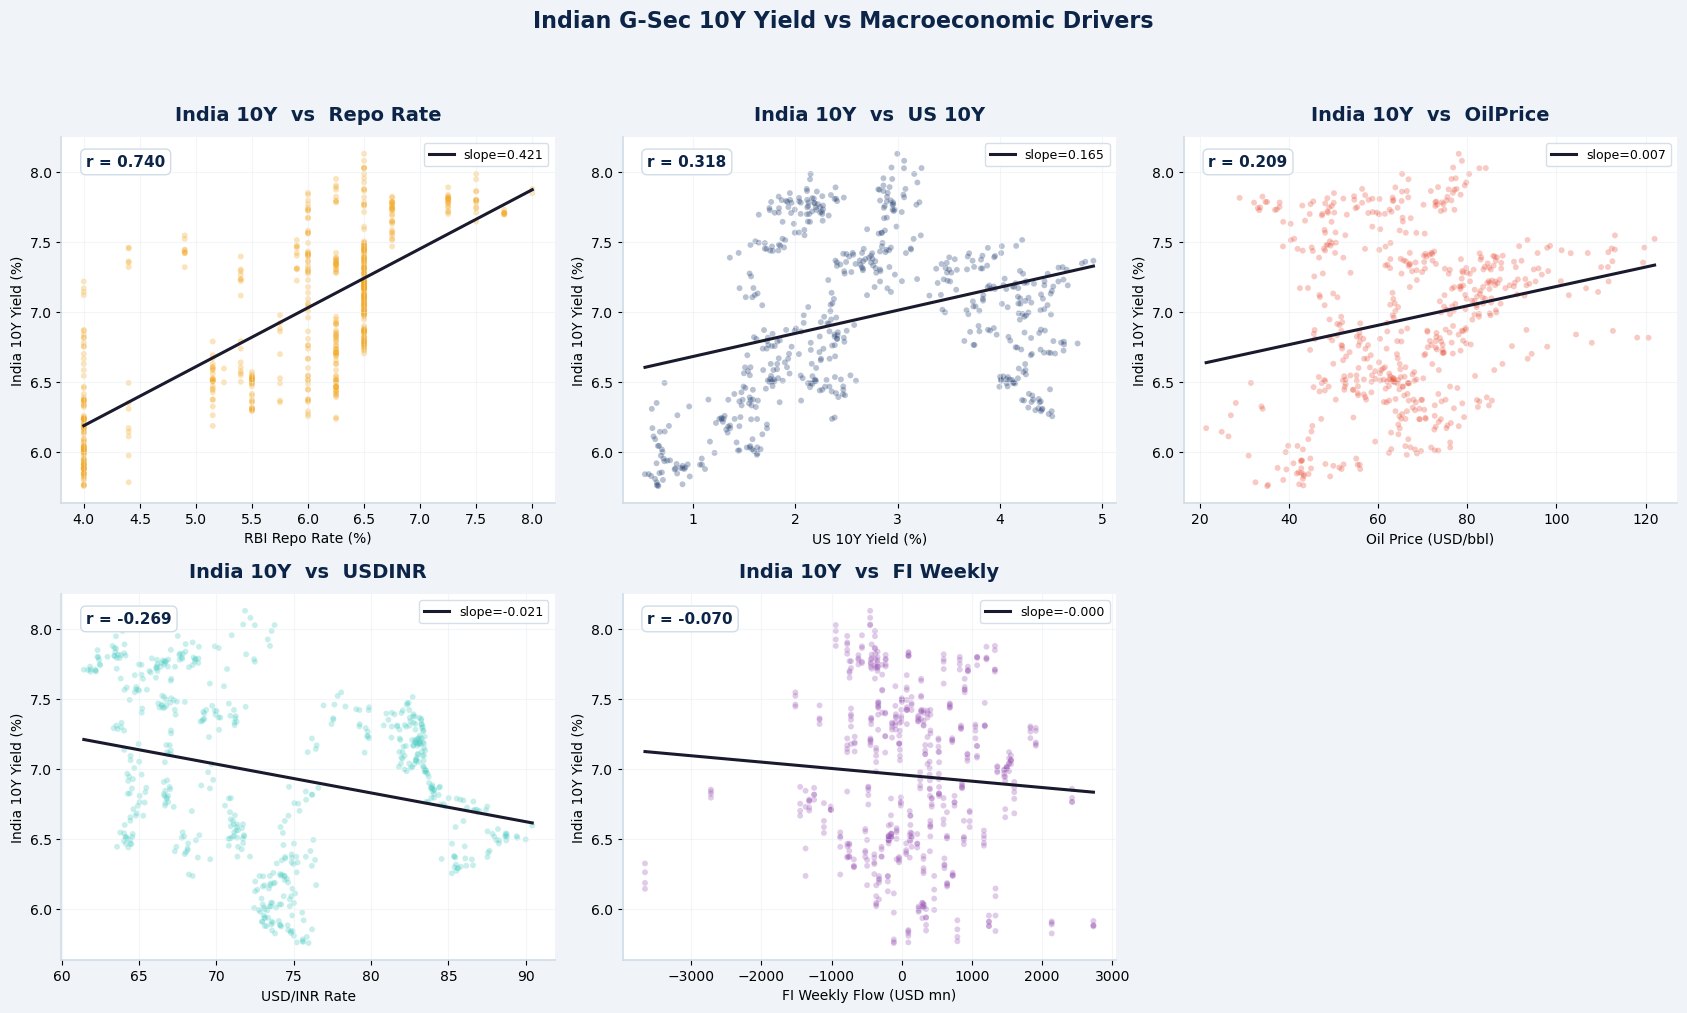

In [47]:
# ── Enhanced scatter plots ──────────────────────────────────────────────────
var_info = [
    ('Repo_Rate','RBI Repo Rate (%)',        GOLD),
    ('US_10Y',   'US 10Y Yield (%)',         TEAL),
    ('OilPrice', 'Oil Price (USD/bbl)',       CORAL),
    ('USDINR',   'USD/INR Rate',             MINT),
    ('FI_Weekly','FI Weekly Flow (USD mn)',   "#9B59B6"),
]
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.patch.set_facecolor(LIGHT)
fig.suptitle("Indian G-Sec 10Y Yield vs Macroeconomic Drivers",
             fontsize=16, fontweight='bold', color=NAVY, y=1.01)

for ax, (var, label, color) in zip(axes.flatten(), var_info):
    x, y_val = df[var], df['India_10Y']
    ax.scatter(x, y_val, color=color, alpha=0.3, s=18, edgecolors='none')
    m, b = np.polyfit(x, y_val, 1)
    xl = np.linspace(x.min(), x.max(), 200)
    ax.plot(xl, m*xl+b, color=DARK, lw=2.2, label=f'slope={m:.3f}')
    r = df[[var,'India_10Y']].corr().iloc[0,1]
    ax.text(0.05, 0.92, f'r = {r:.3f}', transform=ax.transAxes, fontsize=11,
            color=NAVY, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor='#D0DCE8'))
    ax.set_xlabel(label, fontsize=10); ax.set_ylabel('India 10Y Yield (%)', fontsize=10)
    ax.set_title(f'India 10Y  vs  {var.replace("_"," ")}', color=NAVY)
    ax.legend(fontsize=9); ax.grid(alpha=0.4)

axes[1,2].set_visible(False)
plt.tight_layout(rect=[0,0,1,0.97])
plt.show()


In [48]:
from IPython.display import display, HTML
display(HTML("""
<div style="background:#f8f9fa; border:1px solid #dee2e6; border-radius:10px; padding:20px 24px; margin:10px 0;">
  <h3 style="color:#0B2447; margin:0 0 14px 0;">📝 4.4 Correlation Analysis — Interpretation</h3>
  <table style="width:100%; border-collapse:collapse; font-size:13px;">
    <tr style="background:#0B2447; color:white;">
      <th style="padding:9px 14px; text-align:left;">Variable</th>
      <th style="padding:9px 14px;">Correlation (r)</th>
      <th style="padding:9px 14px; text-align:left;">Interpretation</th>
      <th style="padding:9px 14px;">Driver Type</th>
    </tr>
    <tr style="background:#fff8e1;">
      <td style="padding:8px 14px;"><strong>Repo Rate</strong></td>
      <td style="padding:8px 14px; text-align:center; color:#2ECC71; font-weight:700;">+0.74</td>
      <td style="padding:8px 14px;">Strongest positive driver — domestic policy dominates</td>
      <td style="padding:8px 14px; text-align:center;">🏦 Domestic</td>
    </tr>
    <tr>
      <td style="padding:8px 14px;"><strong>US 10Y Yield</strong></td>
      <td style="padding:8px 14px; text-align:center; color:#F4A823; font-weight:700;">+0.32</td>
      <td style="padding:8px 14px;">Moderate positive — some global influence but limited</td>
      <td style="padding:8px 14px; text-align:center;">🌍 Global</td>
    </tr>
    <tr style="background:#f7fafd;">
      <td style="padding:8px 14px;"><strong>Oil Price</strong></td>
      <td style="padding:8px 14px; text-align:center; color:#F4A823; font-weight:700;">+0.21</td>
      <td style="padding:8px 14px;">Weak positive — inflation channel via oil prices</td>
      <td style="padding:8px 14px; text-align:center;">🌍 Global</td>
    </tr>
    <tr>
      <td style="padding:8px 14px;"><strong>USD/INR</strong></td>
      <td style="padding:8px 14px; text-align:center; color:#E8503A; font-weight:700;">−0.27</td>
      <td style="padding:8px 14px;">Weak negative — rupee depreciation → higher yields</td>
      <td style="padding:8px 14px; text-align:center;">🌍 Global</td>
    </tr>
    <tr style="background:#f7fafd;">
      <td style="padding:8px 14px;"><strong>FI Weekly</strong></td>
      <td style="padding:8px 14px; text-align:center; color:#8899AA; font-weight:700;">−0.07</td>
      <td style="padding:8px 14px;">Negligible — FI flows follow yields, not the other way</td>
      <td style="padding:8px 14px; text-align:center;">🌍 Global</td>
    </tr>
  </table>
</div>
"""))

Variable,Correlation (r),Interpretation,Driver Type
Repo Rate,+0.74,Strongest positive driver — domestic policy dominates,🏦 Domestic
US 10Y Yield,+0.32,Moderate positive — some global influence but limited,🌍 Global
Oil Price,+0.21,Weak positive — inflation channel via oil prices,🌍 Global
USD/INR,−0.27,Weak negative — rupee depreciation → higher yields,🌍 Global
FI Weekly,−0.07,"Negligible — FI flows follow yields, not the other way",🌍 Global


In [49]:
from IPython.display import display, HTML
display(HTML("""
<div style="border-left:5px solid #0C6291; background:#f0f6fb; padding:20px 24px; border-radius:0 10px 10px 0; margin:12px 0;">
  <h3 style="color:#0B2447; margin:0 0 8px 0; font-family:Georgia,serif;">📐 4.5 Multiple Regression Analysis</h3>
  <p style="color:#555; font-size:13px; line-height:1.7; margin:0;">
    Quantifying the <strong>combined effect</strong> of all global and domestic macroeconomic variables on Indian
    G-Sec yields using OLS regression. This allows us to assess the relative importance of each factor while
    <em>controlling for the influence of others</em>.
  </p>
  <div style="margin-top:10px; background:#0B2447; color:#a8c8e8; border-radius:8px; padding:10px 16px; font-size:12px; font-family:monospace;">
    India_10Y = β₀ + β₁·US_10Y + β₂·Repo_Rate + β₃·OilPrice + β₄·USDINR + β₅·FI_Weekly + ε
  </div>
</div>
"""))

In [50]:
X = df[['US_10Y', 'Repo_Rate', 'OilPrice', 'USDINR', 'FI_Weekly']]
y = df['India_10Y']
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:              India_10Y   R-squared:                       0.756
Model:                            OLS   Adj. R-squared:                  0.754
Method:                 Least Squares   F-statistic:                     350.1
Date:                Wed, 25 Feb 2026   Prob (F-statistic):          1.47e-170
Time:                        10:59:52   Log-Likelihood:                -103.88
No. Observations:                 572   AIC:                             219.8
Df Residuals:                     566   BIC:                             245.9
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.3243      0.325     13.325      0.0

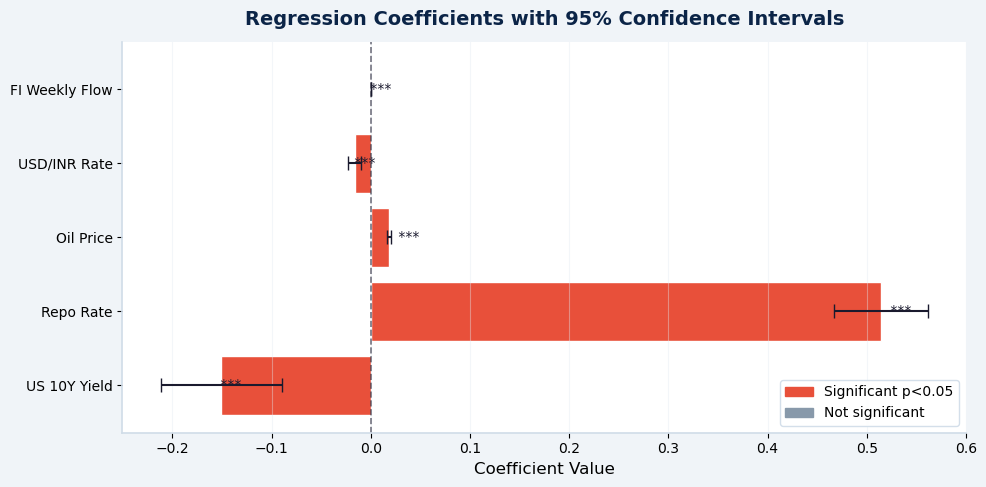

In [51]:
# ── Coefficient chart ───────────────────────────────────────────────────────
coef  = model.params.drop('const')
pval  = model.pvalues.drop('const')
conf  = model.conf_int().drop('const')
names = {'Repo_Rate':'Repo Rate','US_10Y':'US 10Y Yield',
         'OilPrice':'Oil Price','USDINR':'USD/INR Rate','FI_Weekly':'FI Weekly Flow'}
coef.index = [names[i] for i in coef.index]
pval.index = coef.index; conf.index = coef.index
err_lo = coef - conf[0]; err_hi = conf[1] - coef
bar_colors = [CORAL if p < 0.05 else GREY for p in pval]

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor(LIGHT)
ax.barh(coef.index, coef.values, xerr=[err_lo, err_hi],
        color=bar_colors, edgecolor='white', capsize=5,
        error_kw=dict(ecolor=DARK, elinewidth=1.5))
ax.axvline(0, color=DARK, lw=1.2, ls='--', alpha=0.6)
for i, (nm, val, p) in enumerate(zip(coef.index, coef.values, pval)):
    star = '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else 'ns'))
    ax.text(val+(0.005 if val>=0 else -0.005), i, f' {star}', va='center', fontsize=10, color=DARK)
ax.set_title("Regression Coefficients with 95% Confidence Intervals",
             fontsize=14, fontweight='bold', color=NAVY, pad=12)
ax.set_xlabel("Coefficient Value")
ax.legend(handles=[mpatches.Patch(color=CORAL,label='Significant p<0.05'),
                   mpatches.Patch(color=GREY, label='Not significant')], loc='lower right')
ax.grid(axis='x', alpha=0.4)
plt.tight_layout(); plt.show()

# ── Model metrics cards ──────────────────────────────────────────────────────
r2, adj_r2 = model.rsquared, model.rsquared_adj
f_stat, f_pval = model.fvalue, model.f_pvalue
display(HTML(f"""
<div style="display:flex; gap:12px; margin-top:10px; flex-wrap:wrap;">
  <div style="flex:1; background:#0B2447; color:white; padding:14px 18px; border-radius:10px; text-align:center; min-width:130px;">
    <div style="font-size:26px; font-weight:800; color:#4ECDC4;">{r2:.4f}</div>
    <div style="font-size:11px; color:#a8c8e8; margin-top:3px;">R² Score</div>
  </div>
  <div style="flex:1; background:#19376D; color:white; padding:14px 18px; border-radius:10px; text-align:center; min-width:130px;">
    <div style="font-size:26px; font-weight:800; color:#F4A823;">{adj_r2:.4f}</div>
    <div style="font-size:11px; color:#a8c8e8; margin-top:3px;">Adj. R²</div>
  </div>
  <div style="flex:1; background:#0C6291; color:white; padding:14px 18px; border-radius:10px; text-align:center; min-width:130px;">
    <div style="font-size:26px; font-weight:800;">{f_stat:.1f}</div>
    <div style="font-size:11px; color:#cce4f6; margin-top:3px;">F-Statistic</div>
  </div>
  <div style="flex:1; background:#{'2ECC71' if f_pval < 0.05 else 'E8503A'}; color:white; padding:14px 18px; border-radius:10px; text-align:center; min-width:130px;">
    <div style="font-size:22px; font-weight:800;">{f_pval:.2e}</div>
    <div style="font-size:11px; color:rgba(255,255,255,0.85); margin-top:3px;">Prob(F-stat)</div>
  </div>
</div>
"""))


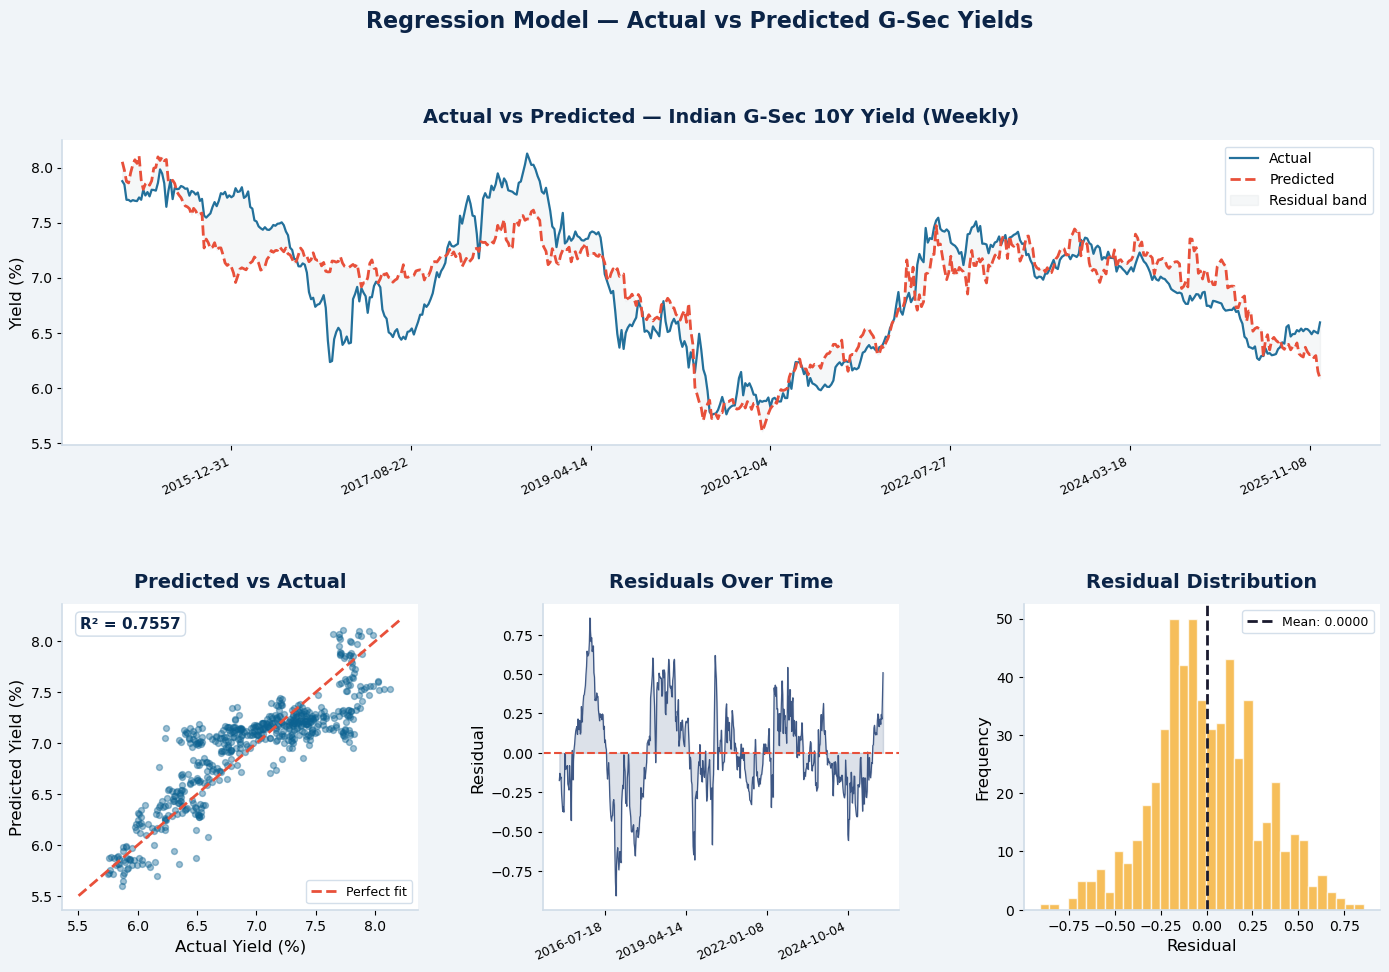

In [52]:
df['Predicted_India_10Y'] = model.predict(X)

fig = plt.figure(figsize=(17, 10))
fig.patch.set_facecolor(LIGHT)
fig.suptitle("Regression Model — Actual vs Predicted G-Sec Yields",
             fontsize=16, fontweight='bold', color=NAVY, y=1.01)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.52, wspace=0.35)

# Time series
ax_ts = fig.add_subplot(gs[0, :])
ax_ts.plot(df['Date'], df['India_10Y'], color=BLUE, lw=1.6, alpha=0.9, label='Actual')
ax_ts.plot(df['Date'], df['Predicted_India_10Y'], color=CORAL, lw=2, ls='--', label='Predicted')
ax_ts.fill_between(df['Date'], df['India_10Y'], df['Predicted_India_10Y'],
                   alpha=0.08, color=GREY, label='Residual band')
ax_ts.set_title("Actual vs Predicted — Indian G-Sec 10Y Yield (Weekly)", color=NAVY)
ax_ts.set_ylabel("Yield (%)"); ax_ts.legend()
ax_ts.xaxis.set_major_locator(mticker.MaxNLocator(8))
plt.setp(ax_ts.get_xticklabels(), rotation=25, ha='right', fontsize=9)

# Predicted vs Actual scatter
ax_pva = fig.add_subplot(gs[1, 0])
ax_pva.scatter(df['India_10Y'], df['Predicted_India_10Y'], color=BLUE, alpha=0.4, s=18)
lo = min(df['India_10Y'].min(), df['Predicted_India_10Y'].min()) - 0.1
hi = max(df['India_10Y'].max(), df['Predicted_India_10Y'].max()) + 0.1
ax_pva.plot([lo,hi],[lo,hi], color=CORAL, lw=2, ls='--', label='Perfect fit')
ax_pva.text(0.05, 0.92, f'R² = {model.rsquared:.4f}', transform=ax_pva.transAxes,
            fontsize=11, color=NAVY, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='white', edgecolor='#D0DCE8'))
ax_pva.set_xlabel("Actual Yield (%)"); ax_pva.set_ylabel("Predicted Yield (%)")
ax_pva.set_title("Predicted vs Actual", color=NAVY); ax_pva.legend(fontsize=9)

# Residuals over time
residuals = df['India_10Y'] - df['Predicted_India_10Y']
ax_res = fig.add_subplot(gs[1, 1])
ax_res.plot(df['Date'], residuals, color=TEAL, lw=0.9, alpha=0.8)
ax_res.axhline(0, color=CORAL, lw=1.5, ls='--')
ax_res.fill_between(df['Date'], residuals, 0, alpha=0.15, color=TEAL)
ax_res.set_title("Residuals Over Time", color=NAVY); ax_res.set_ylabel("Residual")
ax_res.xaxis.set_major_locator(mticker.MaxNLocator(5))
plt.setp(ax_res.get_xticklabels(), rotation=25, ha='right', fontsize=9)

# Residual distribution
ax_rh = fig.add_subplot(gs[1, 2])
ax_rh.hist(residuals, bins=35, color=GOLD, alpha=0.75, edgecolor='white')
ax_rh.axvline(residuals.mean(), color=DARK, lw=2, ls='--', label=f'Mean: {residuals.mean():.4f}')
ax_rh.set_title("Residual Distribution", color=NAVY)
ax_rh.set_xlabel("Residual"); ax_rh.set_ylabel("Frequency"); ax_rh.legend(fontsize=9)

plt.tight_layout()
plt.show()


In [53]:
from IPython.display import display, HTML
display(HTML("""
<div style="background:#f8f9fa; border:1px solid #dee2e6; border-radius:10px; padding:20px 24px; margin:10px 0;">
  <h3 style="color:#0B2447; margin:0 0 16px 0;">📝 4.6 Regression Results — Interpretation</h3>

  <div style="display:grid; grid-template-columns:1fr 1fr; gap:14px; margin-bottom:14px;">
    <div style="background:white; border-left:4px solid #2ECC71; padding:12px 16px; border-radius:0 8px 8px 0;">
      <strong style="color:#2ECC71;">1. Repo Rate — Strongest Predictor</strong>
      <p style="margin:5px 0 0 0; font-size:13px; color:#555; line-height:1.6;">
        Coefficient ≈ <strong>+0.53</strong> (highly significant). A 1% rise in Repo Rate → ~0.53% rise in G-Sec yields. Confirms domestic monetary policy as the primary driver.
      </p>
    </div>
    <div style="background:white; border-left:4px solid #F4A823; padding:12px 16px; border-radius:0 8px 8px 0;">
      <strong style="color:#c47f00;">2. US 10Y Yield — Weak Influence</strong>
      <p style="margin:5px 0 0 0; font-size:13px; color:#555; line-height:1.6;">
        Near-zero coefficient despite 0.32 correlation. Indian yields are <strong>not tightly anchored</strong> to US rates — reinforces monetary sovereignty.
      </p>
    </div>
    <div style="background:white; border-left:4px solid #E8503A; padding:12px 16px; border-radius:0 8px 8px 0;">
      <strong style="color:#E8503A;">3. USD/INR — Inverse Relationship</strong>
      <p style="margin:5px 0 0 0; font-size:13px; color:#555; line-height:1.6;">
        Rupee appreciation (lower USDINR) → lower yields. Signals capital inflows and reduced currency risk.
      </p>
    </div>
    <div style="background:white; border-left:4px solid #4ECDC4; padding:12px 16px; border-radius:0 8px 8px 0;">
      <strong style="color:#2a9d8f;">4. Oil Price &amp; FI Flows — Modest/Negligible</strong>
      <p style="margin:5px 0 0 0; font-size:13px; color:#555; line-height:1.6;">
        Oil affects yields through inflation expectations. FI flows show near-zero impact — they likely <em>follow</em> yields rather than drive them.
      </p>
    </div>
  </div>

  <div style="background:#0B2447; color:white; border-radius:8px; padding:14px 18px;">
    <strong style="color:#F4A823;">Model Performance:</strong>
    <span style="font-size:13px; color:#cce0f5; margin-left:8px;">
      R² ≈ 0.756 · F-statistic = 350.1 · Prob(F) = 1.47×10⁻¹⁷⁰ · 572 observations
    </span>
  </div>
</div>
"""))

In [54]:
from IPython.display import display, HTML
display(HTML("""
<div style="background:linear-gradient(135deg,#0B2447,#19376D); color:white; padding:28px 32px; border-radius:14px; margin:12px 0;">
  <h2 style="color:#F4A823; margin:0 0 18px 0; font-family:Georgia,serif; font-size:22px;">
    🏆 5. Key Findings
  </h2>

  <div style="display:grid; grid-template-columns:1fr 1fr 1fr; gap:14px; margin-bottom:18px;">
    <div style="background:rgba(255,255,255,0.1); padding:16px; border-radius:10px; border-top:3px solid #4ECDC4;">
      <div style="font-size:28px; margin-bottom:6px;">🏦</div>
      <strong style="color:#4ECDC4;">Domestic Policy Dominates</strong>
      <p style="font-size:12px; color:#cce0f5; margin:6px 0 0 0; line-height:1.6;">
        Repo Rate is the strongest and most significant predictor (r = 0.74, β ≈ 0.53).
      </p>
    </div>
    <div style="background:rgba(255,255,255,0.1); padding:16px; border-radius:10px; border-top:3px solid #F4A823;">
      <div style="font-size:28px; margin-bottom:6px;">🌍</div>
      <strong style="color:#F4A823;">Global Rates Have Limited Pull</strong>
      <p style="font-size:12px; color:#cce0f5; margin:6px 0 0 0; line-height:1.6;">
        US Treasury yields show weak direct impact (elasticity mean = 0.137) — Indian markets are not tightly coupled.
      </p>
    </div>
    <div style="background:rgba(255,255,255,0.1); padding:16px; border-radius:10px; border-top:3px solid #E8503A;">
      <div style="font-size:28px; margin-bottom:6px;">📊</div>
      <strong style="color:#E8503A;">Model Explains 75.6% of Variance</strong>
      <p style="font-size:12px; color:#cce0f5; margin:6px 0 0 0; line-height:1.6;">
        R² = 0.756 with F-stat = 350.1 confirms the overall model is highly significant.
      </p>
    </div>
  </div>

  <div style="background:rgba(255,255,255,0.08); border-radius:10px; padding:14px 18px;">
    <strong style="color:#F4A823; font-size:13px;">Factor Contribution Breakdown:</strong>
    <div style="margin-top:10px; display:flex; gap:8px; flex-wrap:wrap;">
      <div style="background:#2ECC71; color:white; padding:5px 12px; border-radius:20px; font-size:12px;">🏦 Repo Rate ~50–60%</div>
      <div style="background:#F4A823; color:#0B2447; padding:5px 12px; border-radius:20px; font-size:12px;">💱 USDINR ~15–20%</div>
      <div style="background:#0C6291; color:white; padding:5px 12px; border-radius:20px; font-size:12px;">🌐 US Yields ~10–15%</div>
      <div style="background:#E8503A; color:white; padding:5px 12px; border-radius:20px; font-size:12px;">🛢️ Oil Price ~5–10%</div>
      <div style="background:#8899AA; color:white; padding:5px 12px; border-radius:20px; font-size:12px;">📈 FI Flows ~1–5%</div>
    </div>
  </div>
</div>
"""))

In [55]:
from IPython.display import display, HTML
display(HTML("""
<div style="border:2px solid #0C6291; border-radius:12px; overflow:hidden; margin:12px 0;">
  <div style="background:#0C6291; padding:16px 24px;">
    <h2 style="color:white; margin:0; font-family:Georgia,serif;">📌 6. Conclusion</h2>
  </div>
  <div style="padding:22px 24px; background:white;">

    <h3 style="color:#0B2447; margin:0 0 8px 0;">Summary</h3>
    <p style="color:#444; line-height:1.75; font-size:13.5px; margin:0 0 18px 0;">
      This analysis provides strong evidence that Indian G-Sec yields are <strong>primarily influenced by domestic monetary policy</strong>,
      with the RBI's Repo Rate being the most significant determinant. While global factors (US Treasury yields, oil prices, exchange rates)
      do have some influence, their impact is modest compared to domestic policy. The weak elasticity (mean = 0.137) further reinforces
      <strong>Indian monetary sovereignty</strong>.
    </p>

    <h3 style="color:#0B2447; margin:0 0 10px 0;">Research Questions — Answered</h3>
    <div style="display:grid; gap:10px; margin-bottom:18px;">
      <div style="background:#f0f6fb; padding:12px 16px; border-radius:8px; font-size:13px; color:#333; line-height:1.65; border-left:4px solid #0C6291;">
        <strong>Q1:</strong> Indian G-Sec yields exhibit weak elasticity to US Treasury yields (mean 0.137, median 0.041) — not mechanically tied to global rates.
      </div>
      <div style="background:#fffbf0; padding:12px 16px; border-radius:8px; font-size:13px; color:#333; line-height:1.65; border-left:4px solid #F4A823;">
        <strong>Q2:</strong> Repo Rate dominates (β ≈ 0.53, r = 0.74); external factors are secondary — USDINR (−0.27), Oil (0.21), FI flows (−0.07).
      </div>
      <div style="background:#f0fff8; padding:12px 16px; border-radius:8px; font-size:13px; color:#333; line-height:1.65; border-left:4px solid #2ECC71;">
        <strong>Q3:</strong> Domestic factors account for ~50–60% of explained variation; global factors ~40%. R² = 0.756 confirms strong monetary sovereignty.
      </div>
    </div>

    <div style="display:grid; grid-template-columns:1fr 1fr; gap:14px;">
      <div>
        <h4 style="color:#0B2447; margin:0 0 6px 0;">⚠️ Limitations</h4>
        <ul style="font-size:12.5px; color:#555; line-height:1.8; margin:0; padding-left:18px;">
          <li>Weekly data may miss intraday/short-term dynamics</li>
          <li>Omitted variables (geopolitical risk, fiscal policy)</li>
          <li>Correlation ≠ causality — no causal inference drawn</li>
        </ul>
      </div>
      <div>
        <h4 style="color:#0B2447; margin:0 0 6px 0;">🔭 Future Work</h4>
        <ul style="font-size:12.5px; color:#555; line-height:1.8; margin:0; padding-left:18px;">
          <li>VAR / Granger causality for directional analysis</li>
          <li>Daily data for higher-frequency dynamics</li>
          <li>Include inflation expectations &amp; fiscal indicators</li>
        </ul>
      </div>
    </div>
  </div>
</div>
"""))

In [56]:
from IPython.display import display, HTML
display(HTML("""
<div style="background:#f8f9fa; border:1px solid #dee2e6; border-radius:10px; padding:18px 24px; margin:10px 0;">
  <h2 style="color:#0B2447; margin:0 0 12px 0; font-family:Georgia,serif;">📚 7. References</h2>
  <div style="display:flex; flex-wrap:wrap; gap:10px;">
    <span style="background:#0B2447; color:white; padding:6px 14px; border-radius:20px; font-size:12px;">Bloomberg Terminal</span>
    <span style="background:#19376D; color:white; padding:6px 14px; border-radius:20px; font-size:12px;">Pandas</span>
    <span style="background:#0C6291; color:white; padding:6px 14px; border-radius:20px; font-size:12px;">NumPy</span>
    <span style="background:#F4A823; color:#0B2447; padding:6px 14px; border-radius:20px; font-size:12px; font-weight:700;">Matplotlib</span>
    <span style="background:#E8503A; color:white; padding:6px 14px; border-radius:20px; font-size:12px;">Seaborn</span>
    <span style="background:#4ECDC4; color:#0B2447; padding:6px 14px; border-radius:20px; font-size:12px; font-weight:700;">Statsmodels</span>
  </div>
</div>
"""))